# Final Project: NYC Airbnb Listing Analysis

**Course: PHY/MAT 231 - Think Like a Data Scientist**  
**Semester: Spring 2026**

**Name: Naomi Tefera**

**Date: May 3, 2026**

---

## Project Background
The dataset I chose is a 2024 Airbnb listings dataset for New York City. It consists of thousands of short-term listings across all five neighborhoods and includes 22 columns that describe each property in terms of pricing, location, host characteristics, and property features. Prices in this dataset represent the cost per night for each listing. The dataset also includes attributes, such as ratings, bedrooms, beds, and baths, which were organized and cleaned by the dataset creator so that the data can be very useful for analysis. Since the dataset is already well-organized, it provides users with a clear snapshot of the New York Airbnb market. Its organization will make it easy for me to compare different neighborhoods, examine pricing patterns, and also analyze how listing characteristics relate to availability and demand. 

The reason why I chose this dataset is that it is clean, relatively recent, and highly relevant for understanding real-world pricing patterns in a major city like New York City. Because NYC has so many distinct areas, this dataset is sufficiently rich for meaningful analysis and works well with SQL. Moreover, I have always found housing, pricing, and the way cities structure their neighborhoods really interesting. Airbnb data gives a clear look into how people value different locations, what features make a place more expensive, and how hosts set their prices. 

Moreover, it includes variables like price, neighborhood, ratings, room types, and host details. I cleaned the dataset by replacing non-standard values such as "Not specified", "No license", and "New" with NaN values to make sure I have consistent data types. 

As seen below, the dataset has a mix of numerical and categorical variables. The df.info() output shows us that columns such as price and minimum_nights are numerical, while neighbourhood_group and room_type are categorical.

As for df.describe(), it is the summary statistics that indicate that the average price is around 188 dollars, with a minimum of 10 dollars and a maximum of 100,000 dollars. This very wide difference suggests that the highest-priced listings (outliers) will most likely influence the average price.


## Research Questions
1. How do Airbnb prices vary across NYC boroughs, and which neighborhoods deviate most from their borough's average price?
2. To what extent does room type influence Airbnb listing prices, and does this effect vary across neighborhoods?
3. Do Airbnb hosts with multiple listings exhibit different pricing behavior than hosts with a single listing?

## Setup: Python Analysis

In [92]:
import pandas as pd #This imports pandas so I can work with data tables
import matplotlib.pyplot as plt  #This imports plotting/graph library so I can create graphs

df = pd.read_csv('cleaned_airbnb_nyc_2024.csv')  #This loads the cleaned Airbnb dataset into a DataFrame, and allows me to analyze & work with the data easily
df.head()  #This prints the first 5 rows to make sure the data loaded correctly

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,rating,bedrooms,beds,baths
0,1.990084e+07,Hostel in Brooklyn · ★1.75 · 2 bedrooms · 1 be...,135049810,AlFatiha,Brooklyn,East Flatbush,40.640890,-73.940810,Private room,80,...,2020-08-07,0.05,1,0,0,NaN,1.75,2,1,1.5
1,5.430514e+07,Rental unit in Brooklyn · ★2.0 · 1 bedroom · 1...,284337887,Eibhlin,Brooklyn,Bedford-Stuyvesant,40.687660,-73.926580,Private room,38,...,2023-03-19,0.18,23,270,2,NaN,2.00,1,1,2.0
2,8.219265e+17,Rental unit in New York · ★2.0 · 1 bedroom · 1...,404355372,Kay,Manhattan,Harlem,40.804660,-73.958109,Private room,140,...,2023-08-27,0.42,8,365,4,NaN,2.00,1,1,1.0
3,7.019962e+17,Boutique hotel in New York · ★2.0 · 1 bedroom ...,215565541,LuxUrban,Manhattan,Murray Hill,40.750406,-73.978755,Private room,175,...,2023-01-14,0.23,35,64,2,NaN,2.00,1,1,1.0
4,4.053772e+07,Home in Brooklyn · ★2.0 · 1 bedroom · 1 bed · ...,291033670,Anastasia,Brooklyn,Bedford-Stuyvesant,40.681500,-73.943430,Private room,75,...,2023-09-23,0.19,8,345,1,NaN,2.00,1,1,1.0


In [93]:
df.info()  #This shows us information about the dataset including column names, data types, and missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20758 entries, 0 to 20757
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20758 non-null  float64
 1   name                            20758 non-null  object 
 2   host_id                         20758 non-null  int64  
 3   host_name                       20758 non-null  object 
 4   neighbourhood_group             20758 non-null  object 
 5   neighbourhood                   20758 non-null  object 
 6   latitude                        20758 non-null  float64
 7   longitude                       20758 non-null  float64
 8   room_type                       20758 non-null  object 
 9   price                           20758 non-null  int64  
 10  minimum_nights                  20758 non-null  int64  
 11  number_of_reviews               20758 non-null  int64  
 12  last_review                     

In [94]:
df.describe()  #This gives us the summary statistics for the numerical columns of the dataset; it helps to understand the distributions (min, max, mean, and more)

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,rating,bedrooms,beds,baths
count,2.075800e+04,2.075800e+04,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,17006.000000,20758.000000,20758.000000,20745.000000
mean,3.034044e+17,1.749316e+08,40.726798,-73.939161,187.776616,28.558435,42.642596,1.257910,18.844108,205.990317,10.852105,4.734253,1.306725,1.723721,1.177995
std,3.901216e+17,1.725541e+08,0.060294,0.061403,1022.797208,33.536518,73.561654,1.904661,70.910834,135.087768,21.357071,0.294387,0.877419,1.212272,0.480456
min,2.595000e+03,1.678000e+03,40.500314,-74.249840,10.000000,1.000000,1.000000,0.010000,1.000000,0.000000,0.000000,1.750000,0.000000,1.000000,0.000000
25%,2.708808e+07,2.041738e+07,40.684150,-73.980710,80.000000,30.000000,4.000000,0.210000,1.000000,87.000000,1.000000,4.640000,1.000000,1.000000,1.000000
50%,4.993003e+07,1.087271e+08,40.722820,-73.949587,125.000000,30.000000,14.000000,0.650000,2.000000,215.000000,3.000000,4.810000,1.000000,1.000000,1.000000
75%,7.216019e+17,3.144102e+08,40.763098,-73.917460,199.000000,30.000000,49.000000,1.800000,5.000000,353.000000,15.000000,4.930000,2.000000,2.000000,1.000000
max,1.054376e+18,5.504035e+08,40.911147,-73.713650,100000.000000,1250.000000,1865.000000,75.490000,713.000000,365.000000,1075.000000,5.000000,15.000000,42.000000,15.500000


## Data Cleaning
During the data cleaning process, I encountered minor issues. There were non-standard values such as "Not specified", "No license", and "New", which I then replaced with NaN values, and columns such as bedrooms and baths were converted into numeric formats. This helped me ensure that the dataset was consistent, clean, and suitable for analysis.

## Graph 1: Price by Borough

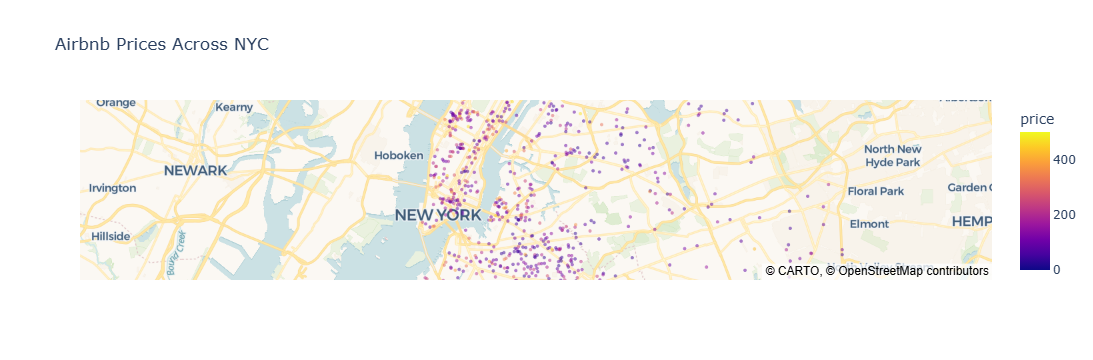

In [109]:
#This creates map of Airbnb listing using latitude and longitude; each dot/point represents a rental in NYC; the color of each point shows the price of that listing

fig = px.scatter_map(
    df_sample,     #This uses a sample of the dataset to make the map less concentrated
    lat ='latitude',  #This sets the latitude (y-axis location on the map)
    lon ='longitude',   #This sets the longitude (x-axis location on the map)
    color ='price',       #This colors each dot/point based on its price
    zoom = 10,               #This zooms into NYC
    range_color=(0, 500),      #This limits the color scale to prices between 0 & 500 for better visualization
    title ='Airbnb Prices Across NYC'  #This adds a title
)

fig.update_traces(marker=dict(size=4, opacity=0.5))   #This adjusts the appearance of the points on the map; it makes them smaller and little transparent so they don't overlap or clutter

fig.show()   #This displays

### Description
This map shows the geographic distribution of Airbnb prices in New York City, with each dot/point representing a rental and the color indicating pricing. As seen, higher-priced listings are concentrated in regions like Manhattan, and affordable listings are more commonly seen in boroughs like the Bronx, Queens, and Staten Island. As for Brooklyn, it shows a mix of midrange and higher-priced offerings, reflecting its expanding popularity. Overall, this map shows clear trends in pricing, explaining that listings in more central and high-demand areas are more expensive, whilst those further from the city are generally considered affordable. To better understand these differences, the bar graph below summarizes the average price by borough, which provides an easier comparison and also helping interpret the patterns observed in the map.

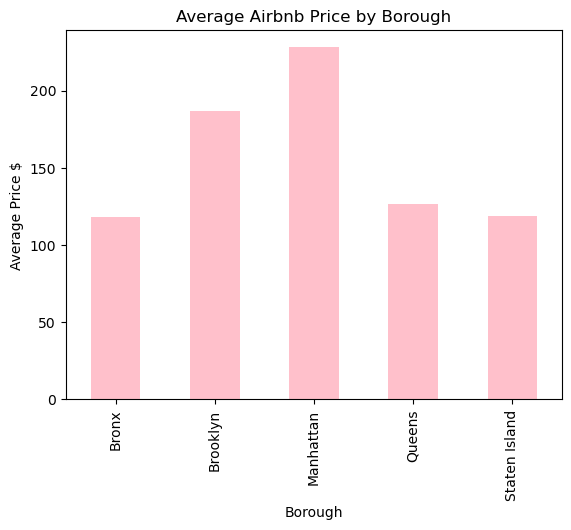

In [96]:
df.groupby('neighbourhood_group')['price'].mean().plot(kind = 'bar', color = 'pink')  #This groups data by borough (neighbourhood_group), calculates the average price for each borough; helps us compare how prices vary across NYC

plt.title('Average Airbnb Price by Borough')  #This adds a title to explain what the graph shows
plt.xlabel('Borough')  #This labels the x-axis as "Borough"
plt.ylabel('Average Price $')  #This labels the y-axis as "Average Price"

plt.show()  #This prints the graph/plot

### Description: 
This bar graph shows the average Airbnb price across NYC boroughs. As seen above, Manhattan has the highest average prices at around 230 dollars, followed by Brooklyn at around 180 dollars. In contrast, Bronx, Queens, and Staten Island offer more affordable options, with average prices of around 120-130 dollars. This suggests that location plays a huge role when it comes to pricing, as more central or high-demand areas like Manhattan and Brooklyn tend to be more expensive than outer boroughs because of their popularity, iconic status, and higher tourist demand.

In [97]:
borough_avg = df.groupby('neighbourhood_group')['price'].mean()  #This calculates the average price for each borough
df['borough_avg'] = df['neighbourhood_group'].map(borough_avg)  #This maps average of borough to each row
df['price_difference'] = df['price'] - df['borough_avg']   #This caluclates how much each listing differs from borough mean

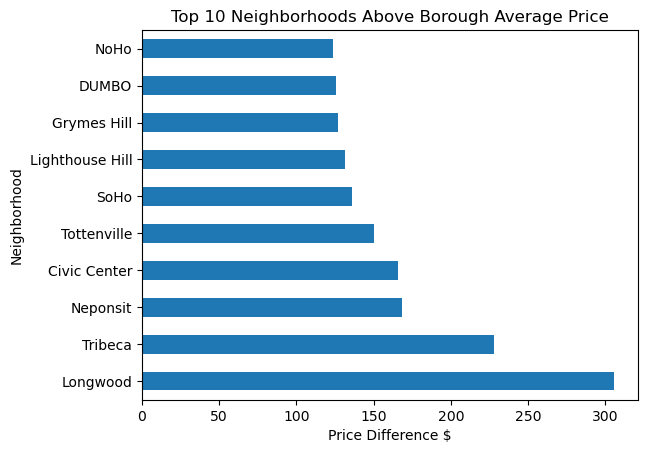

In [98]:
df.groupby('neighbourhood')['price_difference'].mean().sort_values(ascending = False).head(10).plot(kind = 'barh')    #This groups the data by neighbourhood, calculates how much each neighbourhood is above/below its borough mean, then sorts the values from highest to lowest and selects the top 10 to create a horizontal bar chart

plt.title('Top 10 Neighborhoods Above Borough Average Price')  #This adds a title to describe what the graph shows
plt.xlabel('Price Difference $')  #This adds a label for the x-axis (price difference)
plt.ylabel('Neighborhood')  #This adds a label for the y-axis (neighborhood names)

plt.show()   #This displays the horizontal graph                                                                                          

### Description: 
The second graph shows the top 10 neighborhoods above the borough average price. All of the neighborhoods listed on the graph are from different borough groups that are more expensive than the typical listing in their respective boroughs. As seen, Longwood and Tribeca are well above the average, with price differences of around 315 dollars and 230 dollars, respectively, making them among the most pricey areas in their boroughs. Neighborhoods like NoHo and DUMBO also exceed the average, but by a lesser margin of around 130-140 dollars. Overall, this graph helps pinpoint particular locations where Airbnb rentals are priced higher than the average for their borough.

## Graph 2: Room Type vs. Price

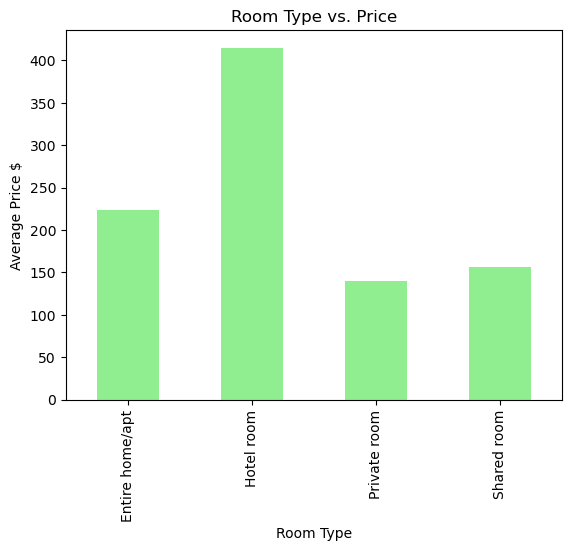

In [99]:
df.groupby('room_type')['price'].mean().plot(kind = 'bar', color = 'lightgreen')  #This groups the data by room type, then calculates the mean price for each type, and shows us how room type affects Airbnb pricing

plt.title('Room Type vs. Price')  #This add a title to explain what the graph is showing
plt.xlabel('Room Type')  #This labels the x-axis as "Room Type"
plt.ylabel('Average Price $')  #This labels the y-axis as "Average Price"

plt.show()  #This prints the graph/plot

### Description:
This bar graph shows the average Airbnb price for each room type. We can see that hotel rooms are the most expensive listings, with an average price of around 420 dollars. The second highest are entire homes/apartments at around 230 dollars, while private and shared rooms charge around 140 dollars and 160 dollars, respectively. It's quite interesting to see that there is a significant price difference between hotel rooms and entire homes/apartments. Both options offer ample space and privacy and are therefore expected to be close in price. However, hotel rooms are much more expensive, which might be due to the extra services they provide, like cleaning, amenities, and in many cases breakfast as well, making them more appealing to guests. Overall, this graph suggests that room type does play a huge role in pricing, as options with more services and offerings tend to be more costly.


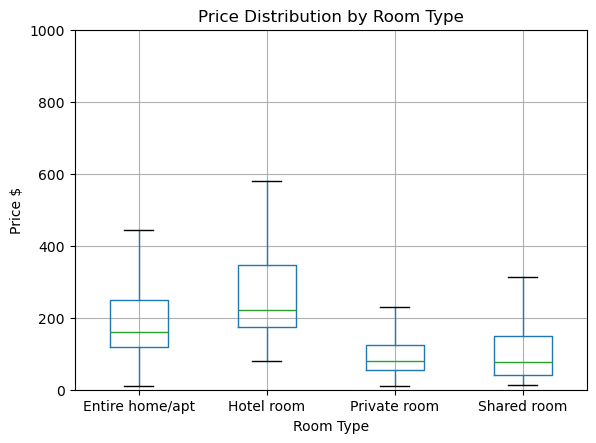

In [100]:
df.boxplot(column = 'price', by = 'room_type', showfliers = False)  #This creates a boxplot of prices for each room type, without showing the extreme outliers for better visualization

plt.title('Price Distribution by Room Type')  #This adds a title to show price distribution by room type
plt.suptitle('')   #Since pandas automatically adds titles, we use this to remove it so we can have our own
plt.xlabel('Room Type')  #This adds a label for the x-axis (room type)
plt.ylabel('Price $')  #This adds a label for the y-axis (price)
plt.ylim(0, 1000)
plt.show()  #This displays the graph

### Description
The boxplot above shows the Airbnb price distribution by each of the four room types. As can be seen above, hotel rooms are relatively the highest priced listings with a median of around 220 dollars, followed by entire homes/apartments at around 180 dollars. On the other hand, private and shared rooms have similar price points at around 60 dollars. Moreover, there is a larger range of prices for entire homes/apartments and hotel rooms, with values as high as 450 dollars and 590 dollars, respectively. As for private and shared rooms, they have a smaller variation, at around 220 dollars and 370 dollars, which means that their prices are more consistent and typically less expensive than the other options. Overall, these boxplots indicate that the type of room has a significant impact on Airbnb rates.

## Graph 3: Host Behavior

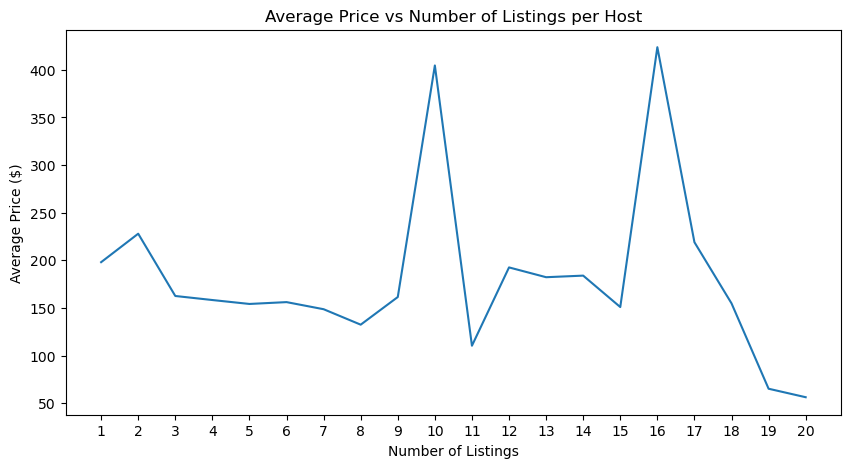

In [101]:
plt.figure(figsize=(10, 5))   #This sets the size of the graph; it makes it more wider so it can be easier to read it

host_price.plot(kind='line')  #This creates a line graph to show how average price changes based on the number of listings a host has

plt.title('Average Price vs Number of Listings per Host')   #This adds a title
plt.xlabel('Number of Listings')   #This labels the x-axis
plt.ylabel('Average Price ($)')    #This labels the y-axis

plt.xticks(range(1, 21))  # This makes sure that the x-axis only uses whole numbers since it will make more sense when reading it (1 to 20 listings)

plt.show()  #This displays the graph

### Description
This line graph shows how the average Airbnb price changes as the number of listings a host has increases, focusing on hosts with up to 20 listings for the purpose of clarity. Based on the graph, we can see that there is no consistent relationship between the number of listings and price, since the values tend to fluctuate across different host sizes. Prices seem to decrease as the number of rentals increases, although this trend is not consistent. Moreover, there are visible spikes at certain points, for example, between 10 and 16 listings, which may be due to fewer hosts having that number of listings or higher-priced listings in popular areas. Overall, we can understand that the number of listings a host has can't be the only factor to determine pricing. It is possible to interpret that hosts with multiple listings could be operating more like businesses and use competitive pricing strategies, while single-listing hosts slightly charge higher prices, since they provide a more unique or personalized property.
Rather, Airbnb prices are likely to be more influenced by other criteria, such as location, unit type, as well as amenities.

## Setup: SQL Analysis

In [102]:
import sqlite3
conn = sqlite3.connect('airbnb.db')
df.to_sql('nyc_listings', conn, if_exists = 'replace', index = False)

20758

## Query 1

In [103]:
query1 = pd.read_sql_query("SELECT neighbourhood_group, AVG(price) AS avg_price FROM nyc_listings GROUP BY neighbourhood_group", conn)  #This calcualtes the average Airbnb price for each borough, and groups the data by neighbourhood_group (borough) and finds mean price
query1  #This displays the table

,neighbourhood_group,avg_price
0,Bronx,118.407798
1,Brooklyn,187.033942
2,Manhattan,227.854193
3,Queens,126.489232
4,Staten Island,118.780069


## Query 2

In [104]:
query2 = pd.read_sql_query("SELECT room_type, AVG(price) AS avg_price FROM nyc_listings GROUP BY room_type", conn)  #This calculates the average Airbnb price for each room type; it groups the data by room_type to compare pricing across the listing types
query2  #This displays the table

,room_type,avg_price
0,Entire home/apt,223.160274
1,Hotel room,415.053571
2,Private room,139.517378
3,Shared room,156.286689


## Query 3

In [105]:
query3 = pd.read_sql_query("SELECT CASE WHEN host_id IN (SELECT host_id FROM nyc_listings GROUP BY host_id HAVING COUNT (*) > 1) THEN 'Multiple Listings' ELSE 'Single Listing' END AS host_type, AVG(price) AS avg_price FROM nyc_listings GROUP BY host_type", conn)
query3

#This is a new technique I learned from DataLemur that uses a CASE statement
#This query divides hosts into two groups: single-listing and multiple-listing
#This time, we use 2 SELECT statements because the first one finds hosts with more than one listing using GROUP BY and COUNT(*)
#Then, we use the second one to label each host from the data as either "Single Listing" or "Multiple Listings" by using the CASE function
#At the end, it calculates the average price for each group

,host_type,avg_price
0,Multiple Listings,178.880176
1,Single Listing,198.066909


### Conclusion
To tie everything together, this analysis provides insight into the various factors that influence Airbnb pricing in New York City. The map with the associated bar graph highlights how location plays a big role in Airbnb pricing throughout New York City, with more expensive alternatives in the outer boroughs and higher prices in popular areas like Manhattan. In addition, the neighborhood analysis shows that some areas, including Longwood and Tribeca, are far more pricey than the borough average. Thus, these results demonstrate that although borough patterns are important, prices can differ significantly within neighborhoods. Moving on to the second question, both the bar graph and the box plot show that room type strongly affects Airbnb pricing. I found that private and shared rooms are relatively cheaper than hotel rooms, which are the most expensive unit types, followed by entire homes/apartments. The boxplot also shows that while private and shared rooms are more consistent and generally less expensive, hotel rooms and entire homes/apartments have a larger range of pricing, indicating more variation. Thus, listings with more privacy, space, and extra services are typically more costly. Lastly, for the final question, the line graph reveals that the number of listings a host has and the price of those listings do not have a consistent relationship. Prices may go down a little as the quantity of listings increases, but this trend is fluctuating and varies depending on host sizes. This implies that price is not only determined by the amount of listings, even though certain hosts with multiple listings could be businesses and employ competitive pricing strategies. Instead, location, type of unit, and amenities are more likely to have a bigger impact on Airbnb rates.